In [2]:
import xarray as xr
ds = xr.open_dataset(r"C:\G\MASTERS\sem4\ResearchProjectMet3d\NAWDIC_CNN_Features\2026_01_20_Dublin\AR_TC_result.nc")
print(ds)

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 61, plev: 1, lat: 768, lon: 1152)
Coordinates:
  * time     (time) datetime64[ns] 488B 2026-01-20 ... 2026-01-27T12:00:00
  * plev     (plev) float64 8B 8.5e+04
  * lat      (lat) float64 6kB -90.0 -89.77 -89.53 -89.3 ... 89.3 89.53 89.77
  * lon      (lon) float64 9kB -180.0 -179.7 -179.4 -179.1 ... 179.1 179.4 179.7
Data variables:
    u        (time, plev, lat, lon) float32 216MB ...
    v        (time, plev, lat, lon) float32 216MB ...
    TQV      (time, lat, lon) float32 216MB ...
    prmsl    (time, lat, lon) float32 216MB ...
    AR       (time, lat, lon) float32 216MB ...
    TC       (time, lat, lon) float32 216MB ...
    TC-LRP   (time, lat, lon) float32 216MB ...
    AR-LRP   (time, lat, lon) float32 216MB ...
Attributes:
    CDI:          Climate Data Interface version 2.3.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  Deutscher Wetterdienst
    history:      Tue Jan 20 06:31:17 2026: cdo -O -s -f nc -r

In [3]:
print(ds["u"])
print(ds["prmsl"])

<xarray.DataArray 'u' (time: 61, plev: 1, lat: 768, lon: 1152)> Size: 216MB
[53968896 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 488B 2026-01-20 ... 2026-01-27T12:00:00
  * plev     (plev) float64 8B 8.5e+04
  * lat      (lat) float64 6kB -90.0 -89.77 -89.53 -89.3 ... 89.3 89.53 89.77
  * lon      (lon) float64 9kB -180.0 -179.7 -179.4 -179.1 ... 179.1 179.4 179.7
Attributes:
    standard_name:  eastward_wind
    long_name:      U component of wind
    units:          m s**-1
    param:          2.2.0
<xarray.DataArray 'prmsl' (time: 61, lat: 768, lon: 1152)> Size: 216MB
[53968896 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 488B 2026-01-20 ... 2026-01-27T12:00:00
  * lat      (lat) float64 6kB -90.0 -89.77 -89.53 -89.3 ... 89.3 89.53 89.77
  * lon      (lon) float64 9kB -180.0 -179.7 -179.4 -179.1 ... 179.1 179.4 179.7
Attributes:
    long_name:  Pressure reduced to MSL
    units:      Pa
    param:      1.3.0


In [4]:
print(ds["AR"])

<xarray.DataArray 'AR' (time: 61, lat: 768, lon: 1152)> Size: 216MB
[53968896 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 488B 2026-01-20 ... 2026-01-27T12:00:00
  * lat      (lat) float64 6kB -90.0 -89.77 -89.53 -89.3 ... 89.3 89.53 89.77
  * lon      (lon) float64 9kB -180.0 -179.7 -179.4 -179.1 ... 179.1 179.4 179.7
Attributes:
    long_name:  Total column integrated water vapour
    units:      kg m-2
    param:      64.1.0


In [5]:
print(ds["TC"])

<xarray.DataArray 'TC' (time: 61, lat: 768, lon: 1152)> Size: 216MB
[53968896 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 488B 2026-01-20 ... 2026-01-27T12:00:00
  * lat      (lat) float64 6kB -90.0 -89.77 -89.53 -89.3 ... 89.3 89.53 89.77
  * lon      (lon) float64 9kB -180.0 -179.7 -179.4 -179.1 ... 179.1 179.4 179.7
Attributes:
    long_name:  Total column integrated water vapour
    units:      kg m-2
    param:      64.1.0


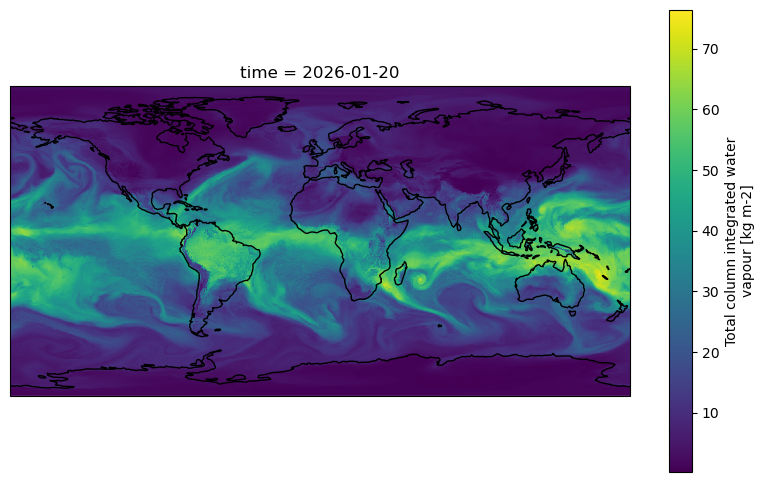

In [6]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())

ds["TQV"].isel(time=0).plot(ax=ax, transform=ccrs.PlateCarree())

ax.coastlines()
plt.show()

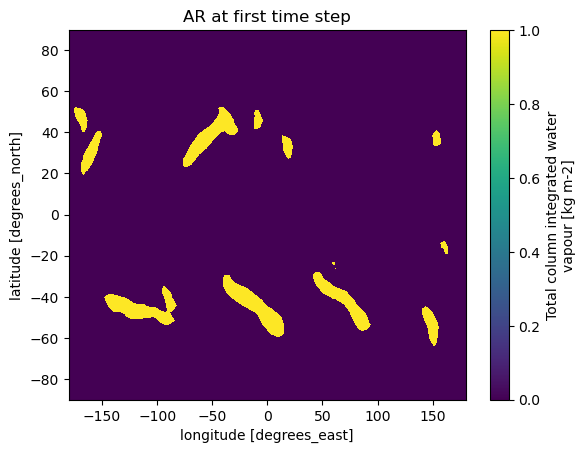

In [7]:
import matplotlib.pyplot as plt
ds["AR"].isel(time=0).plot()
plt.title("AR at first time step")
plt.show()

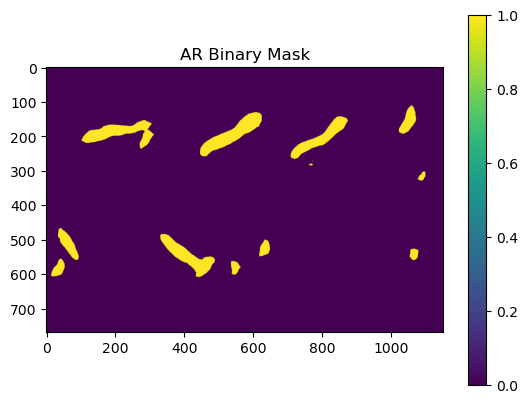

In [8]:
import matplotlib.pyplot as plt

ar = ds["AR"].isel(time=0)

plt.imshow(ar)
plt.title("AR Binary Mask")
plt.colorbar()
plt.show()

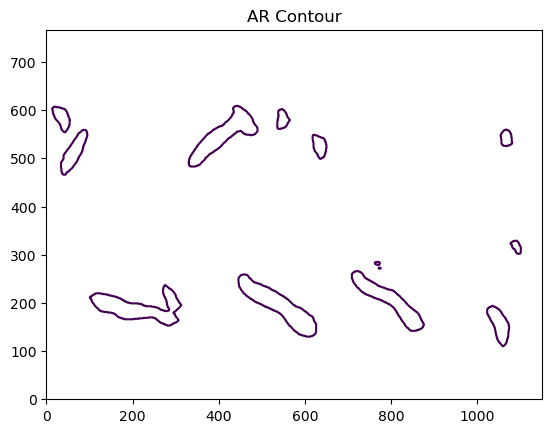

In [ ]:
plt.contour(ar, levels=[0.1])
plt.title("AR Contour")
plt.show()

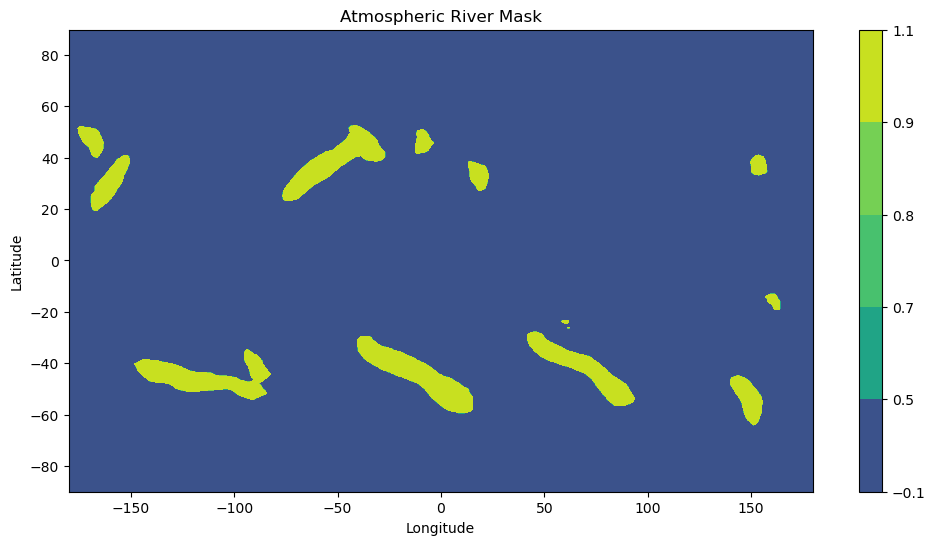

In [ ]:
plt.figure(figsize=(12,6))

plt.contourf(
    ds.lon,
    ds.lat,
    ds["AR"].isel(time=0),
    levels=[-0.1, 0.5, 1.1]
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Atmospheric River Mask")
plt.colorbar()
plt.show()